# **Ejercicios de Econometría: Inferencia**

**IMPORTANTE**
Funciona correctamente en Google Colab usando el entorno de R.

En vstudio puede llegar a tener algunos errores de Latex.

Puede verse mas comodo en Github:
https://github.com/ecalderah

***Edgar Israel Caldera Hernández***

---
## Ejercicio 1

Estás investigando el salario de las mujeres. Este depende de si las mujeres están sindicalizadas o no. Has levantado 3286 encuestas y has obtenido información para las siguientes variables:

* $W_i$: Salario de la mujer i-ésima expresado en dólares por hora.
* $ED_i$: Años de educación formal completados por la i-ésima mujer.
* $EXP_i$: Años de experiencia acumulados por la i-ésima mujer.
* $UN_i$: Variable *dummy* que toma el valor de 1 si la i-ésima mujer está sindicalizada y 0 si no.

Tu modelo consiste en la ecuación log-lineal siguiente:

$$
\ln W_i = \beta_1 + \beta_2 ED_i + \beta_3 EXP_i + \beta_4 ED_i^2 + \beta_5 EXP_i^2 + \beta_6 ED_i EXP_i + \beta_7 UN_i + \beta_8 UN_i ED_i + \beta_9 UN_i EXP_i + \beta_{10} UN_i ED_i^2 + \beta_{11} UN_i EXP_i^2 + \beta_{12} UN_i ED_i EXP_i + u_i \quad (1)
$$

En la ecuación (1), las $\beta_j$ ($j=1, 2, ..., 12$) son los coeficientes de la regresión, $\ln W_i$ es el logaritmo natural de la variable $W_i$ y $u_i$ es un error estocástico.

El Cuadro 1 muestra los resultados de estimar la ecuación (1) en su versión no restringida y tres versiones *restringidas* de la misma ecuación. Los errores estándar se muestran entre paréntesis.

---



Cuadro 1: Resultados de las Regresiones

| Regresores | Regresión 1 (No Restringida) | Regresión 2 | Regresión 3 | Regresión 4 |
| :--- | :---: | :---: | :---: | :---: |
| $\beta_1$ (Constante) | 0.5175<br>(0.2475) | 0.6914<br>(0.2299) | 0.7055<br>(0.2295) | 0.7412<br>(0.2313) |
| $\beta_2$ ($ED$) | 0.08449<br>(0.02894) | 0.0691<br>(0.02666) | 0.06516<br>(0.02655) | 0.05574<br>(0.02674) |
| $\beta_3$ ($EXP$) | 0.040026<br>(0.008062) | 0.03417<br>(0.007574) | 0.03566<br>(0.007524) | 0.03771<br>(0.00758) |
| $\beta_4$ ($ED^2$) | 0.001601<br>(0.0008865) | 0.001837<br>(0.0008112) | 0.001957<br>(0.0008091) | 0.002445<br>(0.000813) |
| $\beta_5$ ($EXP^2$) | -0.0003937<br>(0.000089) | -0.0003664<br>(0.0000879) | -0.0004177<br>(0.0000841) | -0.0004624<br>(0.0000846) |
| $\beta_6$ ($ED \cdot EXP$) | -0.001447<br>(0.0004434) | -0.001096<br>(0.0004094) | -0.001049<br>(0.0004063) | -0.001020<br>(0.0004095) |
| $\beta_7$ ($UN$) | 1.762<br>(0.7416) | -0.007131<br>(0.1059) | 0.1709<br>(0.02311) | --- |
| $\beta_8$ ($UN \cdot ED$) | -0.1526<br>(0.08174) | --- | --- | --- |
| $\beta_9$ ($UN \cdot EXP$) | -0.03941<br>(0.02491) | 0.02097<br>(0.01065) | --- | --- |
| $\beta_{10}$ ($UN \cdot ED^2$) | 0.002564<br>(0.002455) | --- | --- | --- |
| $\beta_{11}$ ($UN \cdot EXP^2$) | -0.0001760<br>(0.0002791) | -0.0005027<br>(0.0002447) | --- | --- |
| $\beta_{12}$ ($UN \cdot ED \cdot EXP$) | 0.0032978<br>(0.001229) | --- | --- | --- |
| **RSS** (Suma de errores al cuadrado) | **698.894** | **700.839** | **701.744** | **713.442** |
| **TSS** (Suma total de cuadrados) | 905.589 | 905.589 | 905.589 | 905.589 |
| **N** (Observaciones) | 3286 | 3286 | 3286 | 3286 |

#### 1. ¿Cuál sería un buen indicador para comparar la bondad de ajuste de los cuatro modelos presentados en el Cuadro 1? ¿Porqué?


**R= La $R^{2}$ ajustado es el mejor indicador puesto que estamos comparando modelos con diferente número de variables, neceistamos una métrica que te diga si la complejidad extra del Modelo 1 realmente aporta la información valiosa o si es mejor quedarse con la simplicidad del modelo 4.**

#### 2.  Calcula y compara la bondad de ajuste de los modelos en el cuadro. ¿Cuál modelo se ajusta mejor a los datos? ¿Cuál se ajusta peor?

* Primero sabemos que n y TSS es la misma para todos

In [1]:
N   <- 3286
TSS <- 905.589

* Podemos calcular $R^2$ y calcularlo a cada modelo sí sintetizamos la información relevante a un df

In [4]:
tabla_com <- data.frame(
  Modelo = c("Regresión 1 (No Restringida)", "Regresión 2", "Regresión 3", "Regresión 4"),
  RSS    = c(698.894, 700.839, 701.744, 713.442),
  k      = c(11, 8, 6, 5)
)

* Aplicamos $$R^{2}=1-\left(\frac{RSS}{TSS}\right)$$

In [11]:
tabla_com$R2 <- 1 - (tabla_com$RSS / TSS)

* La $$R^{2}_{ajustada}=1-\left(\frac{(1-R^{2})*(n-1)}{n-k-1}\right)$$

In [13]:
tabla_com$Adj_R2 <- 1 - ( (1 - tabla_com$R2) * (N - 1) / (N - tabla_com$k - 1))

In [14]:
tabla_com

Modelo,RSS,k,R2,Adj_R2
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Regresión 1 (No Restringida),698.894,11,0.2282437,0.2256508
Regresión 2,700.839,8,0.2260959,0.2242066
Regresión 3,701.744,6,0.2250966,0.2236787
Regresión 4,713.442,5,0.2121790,0.2109781


In [18]:
mejor_modelo <- tabla_com[which.max(tabla_com$Adj_R2), ]
peor_modelo  <- tabla_com[which.min(tabla_com$Adj_R2), ]

cat("El MEJOR ajuste lo tiene:", mejor_modelo$Modelo,
    "con un R2 Ajustado de", mejor_modelo$Adj_R2, "\n")
cat("El PEOR ajuste lo tiene: ", peor_modelo$Modelo,
    "con un R2 Ajustado de", peor_modelo$Adj_R2, "\n")

El MEJOR ajuste lo tiene: Regresión 1 (No Restringida) con un R2 Ajustado de 0.2256508 
El PEOR ajuste lo tiene:  Regresión 4 con un R2 Ajustado de 0.2109781 


#### 3.  Usa los resultados de la Regresión 3 del cuadro para argumentar la siguiente proposición: *Para algún nivel de educación y de experiencia, las mujeres sindicalizadas tienen, en promedio, un salario (en logaritmos) más alto que las empleadas no sindicalizadas.* ¿Cuáles serían la hipótesis nula y la hipótesis alternativa? Calcula el estadístico correspondiente para realizar la prueba. Realiza la prueba para un nivel de confianza del 5%.



 * La Hipótesis nula $(H_0)$ sería que ser sindicalizada no tiene ningun eecto o tiene une fecto negativo al salario.
 $$H_0:β_7 \le 0 $$

 * Y la Hipotesis alternativa sería que ser sindicalizada tienenun efecot positivo en el salario.
 $$H_1:β_7 > 0$$

In [19]:
coe_est_b7 <- 0.1709
se_b7 <- 0.02311

* Sea el estadístico t:
$$t=\frac{\hat{β_7}-0}{se(\hat{β_7})}$$

In [20]:
t <- (coe_est_b7 - 0)/se_b7
t

[1] 7.395067

* Con un nivel de confianza de 95% y $α=00.5$ cuyo valor cítico es 1.645

$$7.395 > 1.645$$

**Podemos afirmar que, según el Modelo 3, las mujeres sindicalizadas tienen, en promedio, un salario (en logaritmos) significativamente más alto que las no sindicalizadas, manteniendo constantes la educación y la experiencia. Específicamente, el coeficiente de 0.1709 sugiere que ganan aproximadamente un 17.1% más.**

#### 4.  ¿Cuáles son las restricciones de la Regresión 2 con respecto a la Regresión 1? Explica intuitivamente el significado de estas restricciones. ¿Cuáles serían la hipótesis nula y la hipótesis alternativa para evaluar la validez de estas restricciones? Calcula el estadístico correspondiente y realiza la prueba con un nivel de confianza del 5%. ¿Cambiaría tu resultado si el nivel de confianza fuera del 1%? En base a tu resultado, ¿cuál regresión elegirías, la 1 o la 2?



* Para pasar de la Regresión 1 (No Restringida) a la Regresión 2, se han eliminado las variables que interactúan el Sindicato ($UN$) con la Educación ($ED$).

* $\beta_8$ (correspondiente a $UN \cdot ED$)

* $\beta_{10}$ (correspondiente a $UN \cdot ED^2$)

* $\beta_{12}$ (correspondiente a $UN \cdot ED \cdot EXP$)Por lo tanto, las restricciones son:$$\beta_8 = 0, \quad \beta_{10} = 0, \quad \beta_{12} = 0$$

* al imponer que $\beta_8, \beta_{10}, \beta_{12}$ sean cero ($H_0$), asume que el rendimiento de la educación es idéntico para mujeres sindicalizadas y no sindicalizadas. Un año más de educación sube el salario en el mismo porcentaje, estés en el sindicato o no.

* Por tanto la hipótesis alternativa ($H_1$): Al menos una de las restricciones es falsa. El modelo no restringido es necesario.$$H_1: \text{Al menos uno de los } \beta \neq 0$$

* Sea el estadístico F:
$$F = \frac{(RSS_R - RSS_{UR}) / q}{RSS_{UR} / (N - k_{UR} - 1)}$$

In [21]:
RSSr <- 700.839
RSSur <- 698.894
q <- 3
n <- 3286
k <- 11

F <- ((RSSr - RSSur)/q)/(RSSur/(n-k-1))
F

[1] 3.037146

* Para la preuba del 5% de ocnfianza el estadistico en la tabla:

$$F_{crit}(3, 3274)=2.60$$

$$F > F_{crit}$$

* Rechazamos ($H_0$). Al 5%: Las restricciones NO son válidas. Los datos indican que el sindicato sí afecta los retornos a la educación.

* Para la prueba del 1%
$$F_{crit}(3, 3274)=3.78$$

$$F_{crit}>F$$

*  No rechazamos ($H_0$).
Al 1%: No hay suficiente evidencia estadística para decir que las restricciones sean falsas.

* **Escogría la Regresión no Restringida, la 1**
  Porque hemos demostrado que quitar esas variables empeora el modelo significativamente. Si nos equivocamos y elegimos la Regresión 2 cuando la 1 es la verdadera (Error Tipo II), nuestros estimadores estarán sesgados (omitimos variables relevantes). Si elegimos la 1 y la 2 era la correcta, solo perdemos un poco de eficiencia (varianza más alta).

#### 5.  Repite el ejercicio anterior para comparar las regresiones 1 y 3, y la 1 y 4. En base a tus resultados, ¿cuál regresión elegirías, la 1 o la 3? ¿La 1 o la 4?


In [30]:
n <- 3286
RSS_nr <- 698.894  # Regresión 1
gl_nr  <- n - 11 - 1 # n - k - 1

# A) Comparar Regresión 1 vs 3 (5 variables quitadas)
F_1vs3 <- ((701.744 - 698.894) / 5) / (698.894 / gl_nr)
critico_F1 <- qf(0.95, df1=5, df2=gl_nr)

# B) Comparar Regresión 1 vs 4 (6 variables quitadas)
F_1vs4 <- ((713.442 - 698.894) / 6) / (698.894 / gl_nr)
critico_F2 <- qf(0.95, df1=6, df2=gl_nr)

# Para mostrar los resultados los pongo en otro df
resultados <- data.frame(
  Comparacion = c("1 vs 3", "1 vs 4"),
  F_Calc      = round(c(F_1vs3, F_1vs4), 2),
  F_Crit      = round(c(critico_F1, critico_F2), 2),
  Gana_Reg1   = c(F_1vs3 > critico_F1, F_1vs4 > critico_F2) # ¿Es mayor?
)

print(resultados)

  Comparacion F_Calc F_Crit Gana_Reg1
1      1 vs 3   2.67   2.22      TRUE
2      1 vs 4  11.36   2.10      TRUE


* Se confirma mi idea original, con forme mas variables menos eficacióa a mis análisis, prefiero quedarme en ete caso con el **modelo no restringido**.

#### 6.  Utiliza la ecuación (1) para calcular el efecto marginal de $ED_i$ sobre el $\ln W_i$ de las mujeres *no sindicalizadas*. Ahora utiliza la Regresión 1 para evaluar la siguiente proposición: *El efecto marginal de $ED_i$ para las empleadas no sindicalizadas es nulo para algún valor de $ED_i$ y de $EXP_i$*. ¿Cuáles serían las restricciones que implica esta proposición? Escribe la hipótesis nula y la hipótesis alternativa. Supón que el RSS del modelo restringido es 836.832. Calcula el estadístico correspondiente. Elige un nivel de confianza apropiado y realiza la prueba.



* Si una mujer no es sindicalizada, la variable dummy es $UN_i = 0$, esto hace que todos los términos que tienen $UN$ en la Ecuación (1) se vuelvan cero.

$$\ln W_i = \beta_1 + \beta_2 ED_i + \beta_3 EXP_i + \beta_4 ED_i^2 + \beta_5 EXP_i^2 + \beta_6 ED_i EXP_i + u_i$$

* Deriamos respecto a ED.
$$\frac{\partial \ln W}{\partial ED} = \beta_2 + 2\beta_4 ED_i + \beta_6 EXP_i$$

* O sea, el efecto de un año más de educación en el salario depende no solo del coeficiente base ($\beta_2$), sino también de cuánta educación ya tiene (por el término cuadrático $\beta_4$) y de cuánta experiencia tiene ($\beta_6$).

* $H_0$: La educación no tiene efecto sobre el salario de las no sindicalizadas.$$H_0: \beta_2 = 0, \beta_4 = 0, \beta_6 = 0$$$
* H_1$: La educación sí tiene efecto (al menos uno de los coeficientes es distinto de cero).

* Ahora calculamos el estadístico F

In [29]:
RSSur <- 698.894
RSSr <- 836.832
q <- 3
n <- 3286
k <- 11

F <- ((RSSr - RSSur)/q)/(RSSur/(n-k-1))
F

[1] 215.3922

* El valor crítico al 5% de confianza es de 2.60

$$215.39 > 2.60$$
Rechazamo H nula. La evidencia muestra que la educación (y sus términos cuadráticos/interacciones) son determinantes fundamentales del salario para este grupo. Eliminar estas variables causaría un error enorme en el modelo y afirmar que el efecto de la ecucación e snula para las mujeres sindicalizadas sería una metnria total.


#### 7.  Utiliza la ecuación (1) para calcular el efecto marginal de $ED_i$ sobre el $\ln W_i$ de las mujeres *sindicalizadas*. Ahora utiliza la Regresión 1 para evaluar la siguiente proposición: *El efecto marginal de $ED_i$ para las empleadas sindicalizadas es nulo para algún valor de $ED_i$ y de $EXP_i$*. ¿Cuáles serían las restricciones que implica esta proposición? Escribe la hipótesis nula y la hipótesis alternativa. Supón que el RSS del modelo restringido es 722.988. Calcula el estadístico correspondiente. Elige un nivel de confianza apropiado y realiza la prueba.

* En contraste al ejercicio 6 donde eliminabamos las variables de sindicato, aca $UN=1$.
El efecto de la educación se vuelve la suma del coeficiente normal más el coeficiente de interacción:

* Efecto Base: $\beta_2$ (Lineal), $\beta_4$ (Cuadrático), $\beta_6$ (Interacción).
* Bonus Sindicato: $\beta_8$ (Lineal), $\beta_{10}$ (Cuadrático), $\beta_{12}$ (Interacción).

Para que el efecto de la educación sea NULO para estas mujeres, el "bonus" debe cancelar exactamente al "base". Esto implica 3 restricciones:

$$\beta_2 + \beta_8 = 0$$
$$\beta_4 + \beta_{10} = 0$$
$$\beta_6 + \beta_{12} = 0$$

In [31]:
RSS_nr <- 698.894    # Regresión 1 (No Restringida)
RSS_restringido_e7 <- 722.988  # Dato del texto del ejercicio 7
q_e7 <- 3

# Denominador: (Error del modelo completo) / grados de libertad
denominador <- RSS_nr / gl_nr

# Estadístico F
F_stat_7 <- ((RSS_restringido_e7 - RSS_nr) / q_e7) / (RSS_nr / gl_nr)

# Valor Crítico al 5%
F_crit_7 <- qf(0.95, df1=q_e7, df2=gl_nr)

# --- RESULTADOS ---
resultados_7 <- data.frame(
  Concepto    = "Efecto Nulo en Sindicalizadas (Ex 7)",
  F_Calculado = round(F_stat_7, 2),
  F_Critico   = round(F_crit_7, 2),
  Decision    = ifelse(F_stat_7 > F_crit_7,
                       "RECHAZAR H0 (El efecto NO es nulo)",
                       "NO RECHAZAR")
)

print(resultados_7)

                              Concepto F_Calculado F_Critico
1 Efecto Nulo en Sindicalizadas (Ex 7)       37.62      2.61
                            Decision
1 RECHAZAR H0 (El efecto NO es nulo)


---
## Ejercicio 2

A partir de datos anuales (1899-1922) para el sector manufacturero en los Estados Unidos, se pueden obtener los siguientes resultados (Dougherty, 1992):

$$
\ln(\hat{Y}) = \underset{(1.38)}{2.81} - \underset{(0.34)}{0.53}\ln K + \underset{(0.14)}{0.91}\ln L + \underset{(0.021)}{0.047}t \quad (1)
$$

donde los errores estándar se muestran entre paréntesis, la $R^2 = 0.97$ y el estadístico $F = 189.8$. En la regresión, $Y$ es un índice de la producción real, $K$ es un índice del capital real, $L$ es un índice del trabajo real y $t$ es el tiempo.

Usando los mismos datos también se obtiene:

$$
\ln(\hat{Y}/L) = \underset{(0.03)}{-0.11} - \underset{(0.15)}{0.11}\ln (K/L) + \underset{(0.006)}{0.006}t \quad (2)
$$

Este modelo arroja una $R^2 = 0.65$ y un estadístico $F = 19.5$.

---

#### 1.  ¿Existe un problema de multicolinealidad en la regresión (1)? ¿Cómo lo sabes?


* Si pues el modelo en conjunto es muy significativo (R² = 0.97, F = 189.8) pero al considerar un t individual por ejemplo la variable capital, $$t = \frac{-0.53}{0.34} \approx -1.56$$ cuyo valor absouo esmenor a 2, por loq ue no rechazamos que sea 0 pero si extremadamente bajo.
Justamente la multicolinealidad infla los errores estándar, haciendo que variables importantes parezcan irrelevantes aunque el modelo global sea bueno.

#### 2.  En la regresión (1), ¿cuál es el signo esperado del $\ln K$? ¿Los resultados confirman esta predicción? ¿Porqué sí o por qué no?


* En una función de producción Cobb Douglas el factor K es un factor d eproucción, si aumentas la cantidad de máquinas o infraestructura (manteniendo constante el trabajo), la producción total ($Y$) debería aumentar. Por tanto, la elasticidad del capital debería ser mayor a cero ($\beta_K > 0$).

* Por lo que **No** confirman la predicción y esto pasa por la multicoinealidad del modelo

#### 3.  ¿Cómo justificas la forma funcional de la regresión (1)?


La teoría económica suele asumir que la relación entre producción ($Y$) e insumos ($K, L$) es multiplicativa y no lineal. La forma original es:$$Y = A e^{\lambda t} K^{\beta_1} L^{\beta_2}$$Donde:$Y$: Producción.$K$: Capital.$L$: Trabajo.$A e^{\lambda t}$: Es la tecnología o "Productividad Total de los Factores", que crece a una tasa constante $\lambda$ en el tiempo ($t$).

Para poder estimar esta curva usando Mínimos Cuadrados Ordinarios (OLS), necesitamos convertirla en una línea recta. Al aplicar logaritmos naturales ($\ln$) a ambos lados, la ecuación multiplicativa se vuelve aditiva:$$\ln(Y) = \ln(A) + \beta_1 \ln(K) + \beta_2 \ln(L) + \lambda t$$
El intercepto es $\ln(A)$.El coeficiente de $t$ es $\lambda$.

#### 4.  Interpreta la regresión (1). ¿Qué papel juega el tiempo en la regresión?


* El coeficiente de ln(k) es 0.53, o sea por 1% más de capital, el producto cae 0.53%, este signo es contrario a la teoría económica el caul se ve afectado por la multicolinealidad.

* El coeficiente ln(L) es 0.91, Un 1% más de trabajo aumenta el producto en 0.91%, lo cual es razonable para una función de producción.

* El tiempo representa el Progreso Tecnológico, captura todo aquello que hace crecer la producción sin necesidad de aumentar la cantidad de máquinas ($K$) o trabajadores ($L$).
Su valor es 0.047 o sea la tecnología (representada por el tiempo) aumenta la producción alrededor de 4.7% anual, incluso sin aumento de factores físicos.

#### 5.  ¿Cuál es la lógica para estimar la regresión (2)?


* Corregir el problema de multicolinealidad presente en la Regresión (1).

* Para lograr esto, se impone una restricción económica específica: Rendimientos Constantes a Escala.
Si suponemos rendimientos constantes a escala, entonces $\alpha + \beta = 1$.
Bajo esta hipótesis, se puede re-escribir la función en términos por trabajador:

$$\frac{Y}{L} = A \left(\frac{K}{L}\right)^{\alpha} e^{g t}$$

y al tomar logaritmos:

$$\ln(Y/L) = \text{constante} + \alpha \ln(K/L) + gt$$

Esta es exactamente la estructura de la regresión (2):

$$\ln(\hat{Y}/L) = -0.11 - 0.11 \ln(K/L) + 0.006 t$$


#### 6.  Si existe multicolinealidad en la regresión (1), ¿este problema se redujo en la regresión (2)? ¿Cómo lo sabes?


* En la Regresión (1), el error estándar del coeficiente de capital (lnK) era 0.34.

* En la Regresión (2), el error estándar del coeficiente de capital (ln(K/L)) bajó a 0.15.

Esto ya nos da mucha precision pero  el coeficiente de $\ln(K/L)$ sigue siendo negativo (-0.11), lo cual sigue contradiciendo la teoría económica.
Además, el estadístico t sigue siendo muy bajo ($t = -0.11 / 0.15 = -0.73$), por lo que la variable sigue siendo no significativa, ayudo a eliminar muticolinealidad pero sigue habeindo problemas de estiamción

#### 7.  Si la regresión (2) es una versión restringida de la regresión (1), ¿cuál fue la restricción impuesta por el autor? ¿Cómo sabes que esta restricción es válida? ¿Qué test utilizarías? Muestra todos tus cálculos.


* La restricción impuesta por el autor es la de Rendimientos Constantes a Escala. Esto implica asumir que la suma de las elasticidades del capital y el trabajo es igual a la unidad:$$\beta_K + \beta_L = 1$$

* Dado que disponemos de los coeficientes y sus errores estándar, el test adecuado es una Prueba t para una combinación lineal de parámetros

* Hipótesis Nula ($H_0$): $\beta_K + \beta_L = 1$ (La restricción es válida).

* Hipótesis Alternativa ($H_1$): $\beta_K + \beta_L \neq 1$.Datos (de la Regresión 1):$\hat{\beta}_K = -0.53$$\hat{\beta}_L = 0.91$
* Error Estándar aproximado de la suma (asumiendo covarianza cero):$$se(\hat{\beta}_K + \hat{\beta}_L) = \sqrt{0.34^2 + 0.14^2} \approx 0.3677$$
* Cálculo del Estadístico t:$$t = \frac{(\hat{\beta}_K + \hat{\beta}_L) - 1}{se} = \frac{(-0.53 + 0.91) - 1}{0.3677} = \frac{-0.62}{0.3677} \approx \mathbf{-1.686}$$

* Utilizando una distribución t-Student con 20 grados de libertad (n−k−1=24−3−1), el valor crítico al 5% de confianza es aproximadamente 2.086.

* Como el valor absoluto de nuestro estadístico calculado (∣−1.686∣) es menor que el valor crítico (2.086), no rechazamos la hipótesis nula. Esto significa que la evidencia no contradice la hipótesis de rendimientos constantes a escala. Por lo tanto, el autor hizo bien en imponer la restricción para intentar corregir el modelo.

#### 8.  ¿Se pueden comparar las $R^2$ de las regresiones (1) y (2)? ¿Porqué sí o porqué no? Si tu respuesta es no, ¿cómo harías para que fueran comparables?

* **No** Porque la variable dependiente (el lado izquierdo de la ecuación) es diferente.Regresión (1): La variable dependiente es $\ln(Y)$.La $R^2$ mide qué tanto de la varianza de el logaritmo de la producción total explicamos.Regresión (2): La variable dependiente es $\ln(Y/L)$.La $R^2$ mide qué tanto de la varianza de el logaritmo de la productividad por trabajador explicamos.

* Podriamos reescribir con la misma variable dependiente,

$$b+c=1$$

imponiendo esa restricción directamente, manteniendo:

* misma variable dependiente: $\ln Y$
* mismos datos
* mismos regresores transformados por la restricción

Esto genera una regresión restringida con variable dependiente $\ln Y$, y entonces sí puedes comparar $R^2$ y aplicar test F de restricciones lineales.

---
## Ejercicio 3

Se desea representar la tasa de variación salarial ($Y$) en función de la tasa de desempleo ($X$) mediante el modelo con forma funcional recíproca:

$$
Y_i = \beta_1 + \beta_2 \frac{1}{X_i} + u_i
$$

Supongamos que los coeficientes estimados son: $\widehat{\beta_1} = 0.5$ y $\widehat{\beta_2} = 0.4$. Responde lo siguiente.

---



#### ¿El signo de los coeficientes estimados es el esperado?

Lo que dice la ecuación es sí el desempleo es alto ($X \uparrow$): Hay mucha oferta de trabajadores, su poder de negociación baja, por lo que los salarios crecen menos ($Y \downarrow$).
Si el desempleo es bajo ($X \downarrow$): Escasean trabajadores, las empresas pagan más para retenerlos, los salarios suben ($Y \uparrow$).

Para corroborar podemos derivar.
$$\frac{dY}{dX} = -\beta_2 \frac{1}{X^2}$$

Sabemos que $X^2$ siempre es positivo. Para que exista la relación inversa teórica (pendiente negativa), necesitamos que el resultado de esa derivada sea negativo ($<0$).Para que $-\beta_2 \frac{1}{X^2}$ sea negativo, $\beta_2$ debe ser positivo ($\beta_2 > 0$).

Pongmaoslo aprueba con los datos del ejercicio.

In [36]:
beta2 <- 0.4

# Creamos varios escenarios de Tasa de Desempleo (X) desde 2% hasta 10%
X <- c(2, 4, 6, 8, 10)

# Calculamos la pendiente (Efecto Marginal) en cada punto
# dY/dX = -beta2 / (X^2)
pendiente <- -beta2 / (X^2)

# Mostramos los resultados
tabla_verificacion <- data.frame(
  Tasa_Desempleo_X = X,
  Pendiente_dYdX   = round(pendiente, 4),
  Conclusion       = ifelse(pendiente < 0, "Relación Inversa (Correcto)", "Error")
)

print(tabla_verificacion)

  Tasa_Desempleo_X Pendiente_dYdX                  Conclusion
1                2        -0.1000 Relación Inversa (Correcto)
2                4        -0.0250 Relación Inversa (Correcto)
3                6        -0.0111 Relación Inversa (Correcto)
4                8        -0.0063 Relación Inversa (Correcto)
5               10        -0.0040 Relación Inversa (Correcto)


SÍ, es el signo esperado. Confirma la relación inversa: a mayor desempleo, menor variación salarial.

Para el coeficieonte $\hat{\beta}_1$ es 0.5, sí $\beta_1$ es positivo: La curva está flotando "en el aire" por encima del eje. Significa que, incluso si el desempleo fuera infinito ($X \to \infty$), los salarios seguirían subiendo un 0.5%. Económicamente, esto es raro (implica que los salarios nunca pueden caer o estabilizarse, siempre suben).

#### Representa esta función gráficamente.

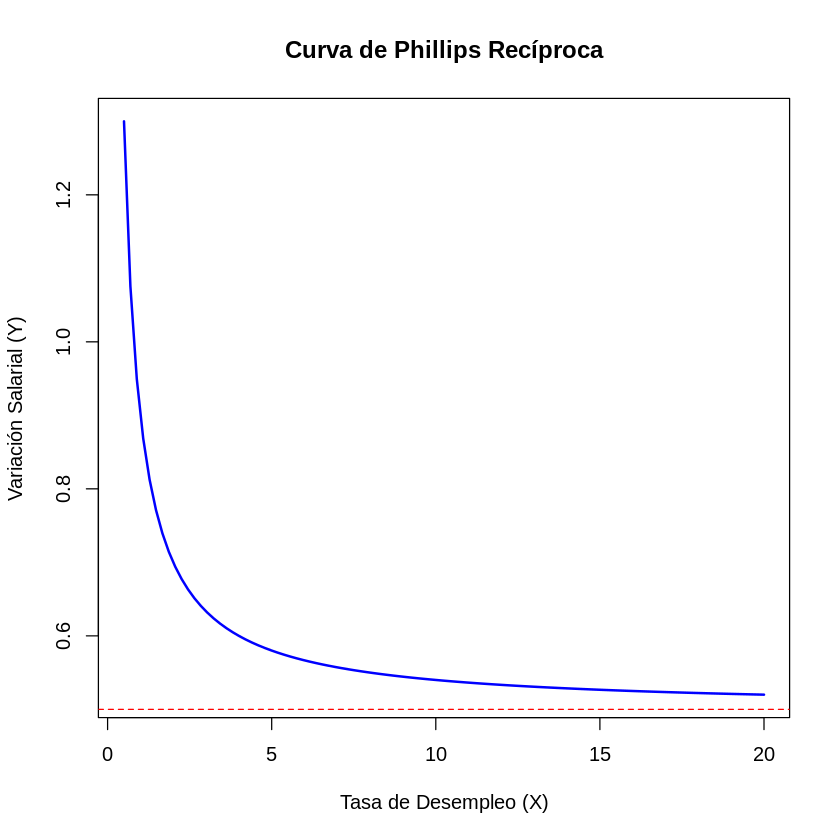

In [37]:
curve(0.5 + 0.4 * (1/x),
      from = 0.5,  # Empezamos en 0.5 para evitar la división por cero
      to = 20,     # Hasta una tasa de desempleo del 20%
      col = "blue",
      lwd = 2,
      ylab = "Variación Salarial (Y)",
      xlab = "Tasa de Desempleo (X)",
      main = "Curva de Phillips Recíproca")

# Agregamos la línea de la asíntota (el "suelo" de 0.5)
abline(h = 0.5, col = "red", lty = 2)

#### Calcula la pendiente y la elasticidad en el punto ($X_{2i} = 0.2; Y_i = 2.5$) e interpreta.

En un modelo recíproco ($Y = \beta_1 + \beta_2 \frac{1}{X}$), la pendiente no es constante; cambia según el valor de $X$. La fórmula se obtiene derivando con respecto a $X$:$$\text{Pendiente} = \frac{dY}{dX} = -\frac{\hat{\beta}_2}{X^2}$$Cálculo:$\hat{\beta}_2 = 0.4$$X = 0.2 $$X^2 = (0.2)^2 = 0.04$
$$\text{Pendiente} = -\frac{0.4}{0.04} = \mathbf{-10}$$

En este punto específico (donde el desempleo es muy bajo, 0.2), la curva es extremadamente empinada. Un aumento unitario en el desempleo provocaría una disminución de 10 unidades en la tasa de variación salarial. Refleja una sensibilidad altísima de los salarios cuando hay casi pleno empleo.

Para la elasticidad:
$$\varepsilon = \text{Pendiente} \cdot \frac{X}{Y}$$

$$\varepsilon = -10 \cdot \left( \frac{0.2}{2.5} \right)$$$$\varepsilon = -10 \cdot 0.08 = \mathbf{-0.8}$$

Si la tasa de desempleo aumenta un 1%, la variación salarial disminuirá un 0.8%.

#